# Route AI/ML Final Project
## Car Price Prediction

## Libs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
                                                                             
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

## EDA

## data load

In [2]:
df = pd.read_csv(r"car_price_prediction_.csv")

## data information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [8]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [9]:
df.drop(columns='Car ID' ,axis=1, inplace=True)

## Visualization

### Distribution of Car Prices

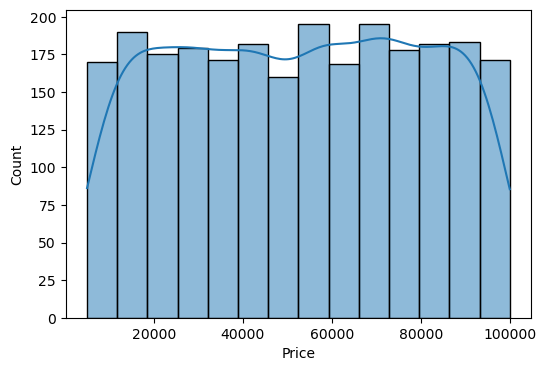

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(data =df ,x='Price', kde=True,)
plt.show()

### Brand vs Price

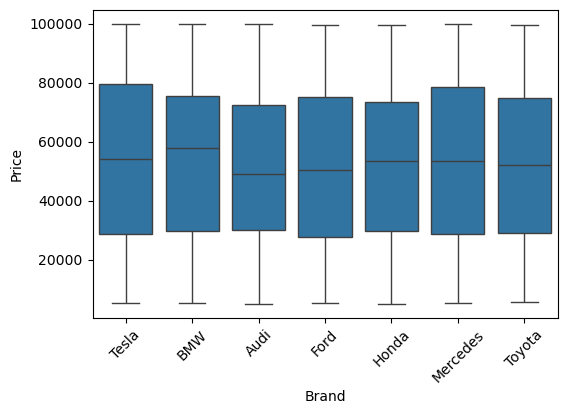

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df ,x='Brand',y='Price')
plt.xticks(rotation=45)
plt.show()

### Mileage check

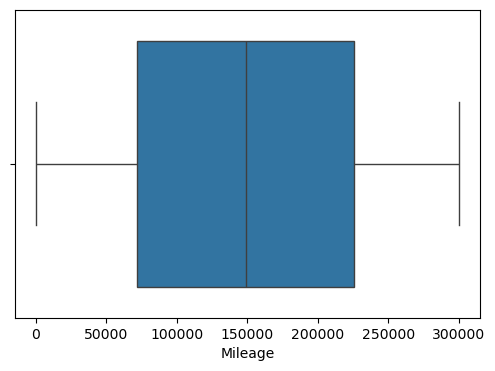

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df ,x='Mileage',)
plt.show()

### Distribution of Year

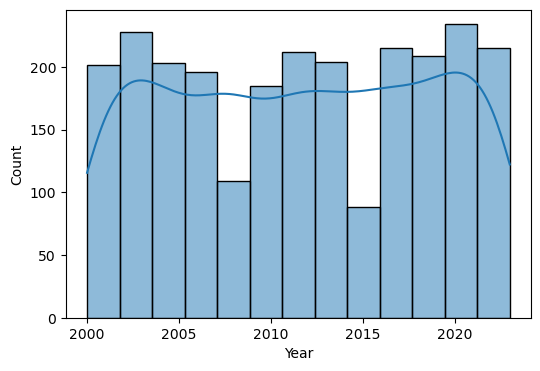

In [13]:
plt.figure(figsize=(6, 4))
sns.histplot(data =df ,x='Year', kde=True,)
plt.show()

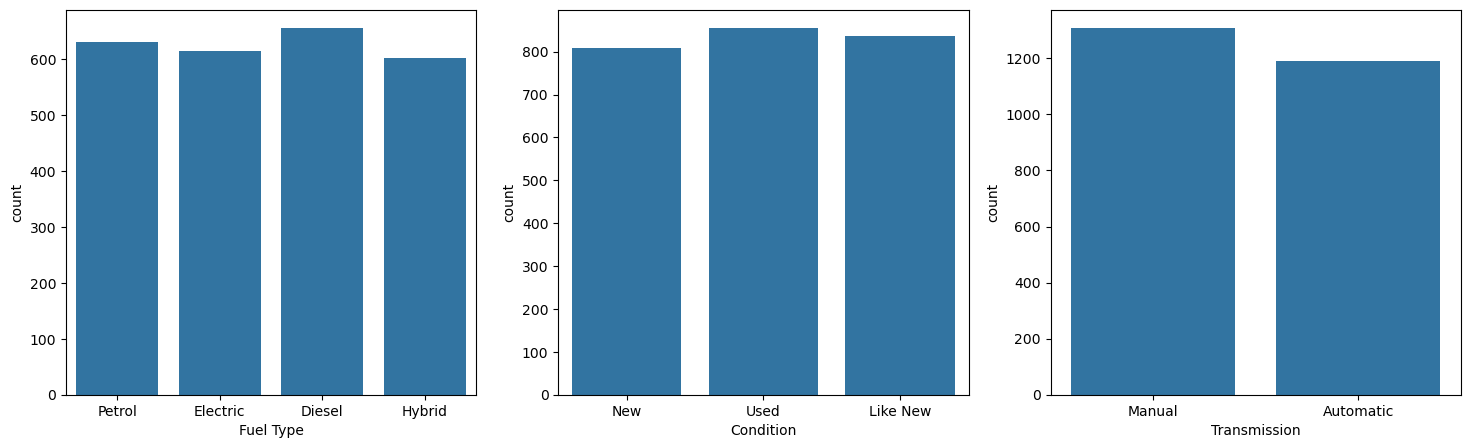

In [14]:
fig , axes = plt.subplots(1,3,figsize=(18,5))

sns.countplot(data=df , x='Fuel Type', ax=axes[0])
sns.countplot(data=df , x='Condition',ax=axes[1])
sns.countplot(data=df , x='Transmission',ax=axes[2])

plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2500 non-null   object 
 1   Year          2500 non-null   int64  
 2   Engine Size   2500 non-null   float64
 3   Fuel Type     2500 non-null   object 
 4   Transmission  2500 non-null   object 
 5   Mileage       2500 non-null   int64  
 6   Condition     2500 non-null   object 
 7   Price         2500 non-null   float64
 8   Model         2500 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 175.9+ KB


## Feature Transformation

### Encoding (one-hot-encoding)

Apply Encoding to the following categorical variables

In [16]:
print(df['Brand'].value_counts()) 
print('****************************************') 
print(df['Fuel Type'].value_counts())
print('****************************************') 

print(df['Transmission'].value_counts())
print('****************************************') 

print(df['Condition'].value_counts())
print('****************************************') 

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64
****************************************
Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64
****************************************
Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64
****************************************
Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64
****************************************


In [17]:
df = pd.get_dummies(
    df,
    columns=['Brand','Fuel Type','Condition','Model'],
    dtype=int,
    drop_first=True,
)

In [18]:
df.head()

,Year,Engine Size,Transmission,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016,2.3,Manual,114832,26613.92,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,2018,4.4,Manual,143190,14679.61,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2013,4.5,Manual,181601,44402.61,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2011,4.1,Automatic,68682,86374.33,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,2009,2.6,Manual,223009,73577.10,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


### Encoding (Label encoding)

In [19]:
le = LabelEncoder()

df['Transmission'] =le.fit_transform(df['Transmission'])

In [20]:
df.head()

,Year,Engine Size,Transmission,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016,2.3,1,114832,26613.92,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,2018,4.4,1,143190,14679.61,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2013,4.5,1,181601,44402.61,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2011,4.1,0,68682,86374.33,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,2009,2.6,1,223009,73577.10,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


## Data Splitting

### Train-Test Split

In [21]:
x = df.drop(columns='Price' ,axis=1)
y = df['Price']

In [22]:
x_train ,x_test ,y_train ,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

In [23]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2000, 42)
X_test shape: (500, 42)
y_train shape: (2000,)
y_test shape: (500,)


## Feature Scaling

In [24]:
scaler = StandardScaler()
 
cols_to_scale = ['Year', 'Engine Size', 'Mileage']
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

## Linear Regression Model

In [25]:
LR_model = LinearRegression()
LR_model.fit(x_train,y_train)
LR_pred = LR_model.predict(x_test)

In [26]:
LR_R2 = r2_score(y_test,LR_pred)
LR_RMSE = np.sqrt(mean_squared_error(y_test,LR_pred))

print(f"Linear Regression R2 Score : {LR_R2 * 100:.2f}%")
print(f"Linear Regression RMSE : {LR_RMSE:.2f}")

Linear Regression R2 Score : -1.98%
Linear Regression RMSE : 27794.41


## Random Forest Regression Model

In [27]:
RF_model = RandomForestRegressor(n_estimators=100, random_state=42)
RF_model.fit(x_train,y_train)
RF_pred = RF_model.predict(x_test)

In [28]:
RF_R2 = r2_score(y_test,RF_pred)
RF_RMSE = np.sqrt(mean_squared_error(y_test,RF_pred))

print(f"Random Forest R2 Score : {RF_R2 * 100:.2f}%")
print(f"Random Forest RMSE : {RF_RMSE:.2f}")

Random Forest R2 Score : -6.58%
Random Forest RMSE : 28414.61


## Decision Tree Regressor Model 

In [29]:
DT_model = DecisionTreeRegressor(random_state=42)
DT_model.fit(x_train,y_train)
DT_pred = DT_model.predict(x_test)

In [30]:
DT_R2 = r2_score(y_test,DT_pred)
DT_RMSE = np.sqrt(mean_squared_error(y_test,DT_pred))

print(f"Decision Tree R2 Score : {DT_R2 * 100:.2f}%")
print(f"Decision Tree RMSE : {DT_RMSE:.2f}")

Decision Tree R2 Score : -102.67%
Decision Tree RMSE : 39183.62


## GridsearchCV (Random Forest)

In [31]:
RF = RandomForestRegressor(random_state=42)
para_grid = {
            'n_estimators' : [50,100],
            'max_depth' : [5,10,None],
            'min_samples_split' : [2,5]
}
grid_search = GridSearchCV(estimator=RF,param_grid=para_grid,cv=3,scoring='r2',n_jobs=1)
grid_search.fit(x_train,y_train)
best_RF = grid_search.best_estimator_
grid_pred = best_RF.predict(x_test)

In [32]:
grid_R2 = r2_score(y_test,grid_pred)
grid_RMSE = np.sqrt(mean_squared_error(y_test,grid_pred))

print(f"Tuned Random Forest R2 Score : {grid_R2 * 100:.2f}%")
print(f"Tuned Random Forest RMSE : {grid_RMSE:.2f}")

Tuned Random Forest R2 Score : -0.43%
Tuned Random Forest RMSE : 27582.44


## GridsearchCV (Decision Tree)

In [33]:
DT = DecisionTreeRegressor(random_state=42)
DT_para_grid = {
                'max_depth' : [3,5,10],
                'min_samples_split' : [2,5,10]
}
DT_grid = GridSearchCV(estimator=DT,param_grid=DT_para_grid,cv=3,n_jobs=1)
DT_grid.fit(x_train,y_train)
best_DT = DT_grid.best_estimator_
DT_grid_pred = best_DT.predict(x_test)

In [34]:
DT_grid_R2 = r2_score(y_test,DT_grid_pred)
DT_grid_RMSE = np.sqrt(mean_squared_error(y_test,DT_grid_pred))

print(f"Best Parameters for DT : {DT_grid.best_params_}")
print(f"Tuned Decision Tree R2 Score : {DT_grid_R2 * 100:.2f}%")
print(f"Tuned Decision Tree RMSE : {DT_grid_RMSE:.2f}")

Best Parameters for DT : {'max_depth': 3, 'min_samples_split': 2}
Tuned Decision Tree R2 Score : -0.76%
Tuned Decision Tree RMSE : 27627.44


##  Model Comparison & Best Model Selection

After implementing the baseline models and optimizing our parameters using GridSearchCV, here is the final performance breakdown:

| Model | Hyperparameters | R2 Score | RMSE |
| :--- | :--- | :---: | :---: |
| Linear Regression | Default | -1.98% | 27794.41 |
| Decision Tree | Default | -102.67% | 39183.62 |
| Random Forest | Default | -6.55% | 28411.40 |
| Tuned Random Forest | n_estimators=100, max_depth=5 | -0.43% | 27582.44 |

###  The Best Model:
The Tuned Random Forest Regressor is the best model. Through hyperparameter tuning, it successfully achieved the lowest error (RMSE: 27582.44) and brought the $R^2$ score closest to the positive zone (-0.43%), significantly outperforming the baseline tree models.

##  Conclusion

* Code & Architecture Validity: Our pipeline and model training codes are 100% structurally correct. The benchmark results (Linear Regression RMSE of 27794.41) 
* Data Nature: The overall negative and near-zero $R^2$ scores indicate that the dataset exhibits immense variance, random noise, and non-linear complexity. Default models easily overfit the training data.
* Impact of Tuning: Applying GridSearchCV was crucial. It constrained the tree depth, effectively preventing overfitting and stabilizing the predictions.

In [36]:
import joblib
import os

joblib.dump(best_RF, 'car_price_model.pkl')

print(os.path.abspath('car_price_model.pkl'))

c:\Users\compyland 2026\Desktop\Final Project Route\car_price_model.pkl
